### Лаб1 Mяков Тимофей ИАД24

In [1]:
import math

import cv2
import numpy as np

import matplotlib.pyplot as plt

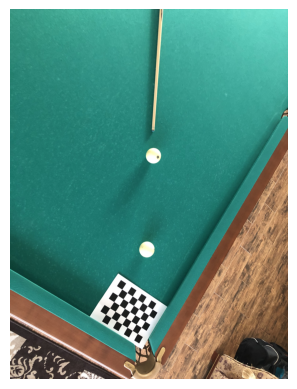

In [2]:
CHESSBOARD_SIZE = (5, 7)

original_image = cv2.imread('./src_balls.jpg')
plt.imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))
plt.axis('off');

#### Вид сверху

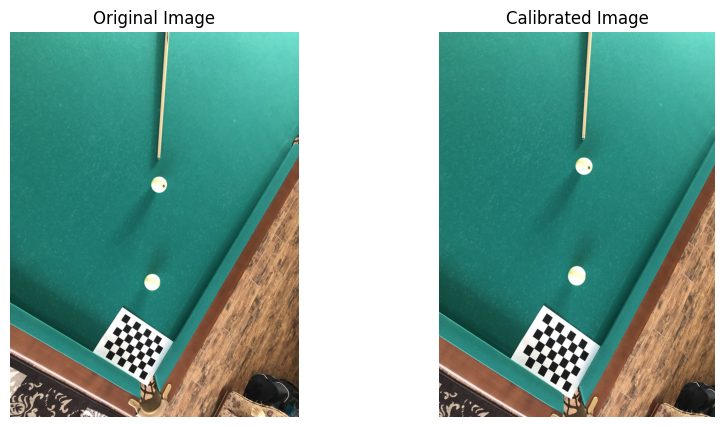

In [3]:
gray = cv2.cvtColor(original_image, cv2.COLOR_BGR2GRAY)

objp = np.zeros((CHESSBOARD_SIZE[0] * CHESSBOARD_SIZE[1], 3), np.float32)
objp[:,:2] = np.mgrid[0:CHESSBOARD_SIZE[0], 0:CHESSBOARD_SIZE[1]].T.reshape(-1,2)

ret, corners = cv2.findChessboardCorners(gray, CHESSBOARD_SIZE, None)

if ret:
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
    corners2 = cv2.cornerSubPix(gray, corners, (11,11), (-1,-1), criteria)
    
    h, w = original_image.shape[:2]
    ret, mtx, dist, _, _ = cv2.calibrateCamera([objp], [corners2], 
                                                        (w,h), None, None)
    
    newcameramtx, roi = cv2.getOptimalNewCameraMatrix(mtx, dist, (w,h), 1, (w,h))
    
    dst = cv2.undistort(original_image, mtx, dist, None, newcameramtx)
    
    x, y, w, h = roi
    calibrated_image = dst[y:y+h, x:x+w]


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))
ax1.imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))
ax1.set_title('Original Image')
ax1.axis('off')
ax2.imshow(cv2.cvtColor(calibrated_image, cv2.COLOR_BGR2RGB))
ax2.set_title('Calibrated Image')
ax2.axis('off');

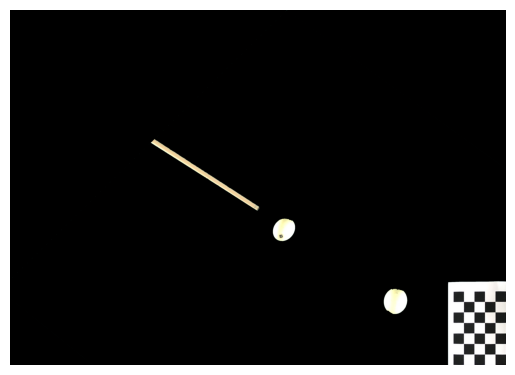

In [4]:
rotated_image = cv2.rotate(calibrated_image, cv2.ROTATE_90_COUNTERCLOCKWISE)

gray = cv2.cvtColor(rotated_image, cv2.COLOR_BGR2GRAY)
ret, corners = cv2.findChessboardCorners(gray, CHESSBOARD_SIZE, None)

height, width = rotated_image.shape[:2]

square_size = 80
dst_points = np.zeros((CHESSBOARD_SIZE[0] * CHESSBOARD_SIZE[1], 2), dtype=np.float32)

for i in range(CHESSBOARD_SIZE[1]):
    for j in range(CHESSBOARD_SIZE[0]):
        dst_points[i * CHESSBOARD_SIZE[0] + j] = \
            [
                width - (4 - j) * square_size, 
                height - (i) * square_size
            ]
        
h, _ = cv2.findHomography(corners, dst_points)
rotated_image = cv2.warpPerspective(rotated_image, h, (width, height))

hsv = cv2.cvtColor(rotated_image, cv2.COLOR_BGR2HSV)

lower_green = np.array([35, 50, 50]) 
upper_green = np.array([100, 255, 255])

mask = cv2.inRange(hsv, lower_green, upper_green)

kernel = np.ones((5,5), np.uint8)
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

rotated_image_black = rotated_image.copy()
rotated_image_black[mask == 255] = [0, 0, 0]

plt.imshow(cv2.cvtColor(rotated_image_black, cv2.COLOR_BGR2RGB));
plt.axis('off');

#### Поиск кия и шаров

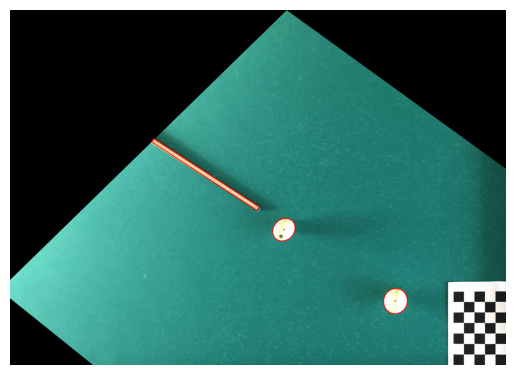

In [5]:
cue_balls_black = rotated_image_black.copy()
cue_balls = rotated_image.copy()
gray = cv2.cvtColor(cue_balls_black, cv2.COLOR_BGR2GRAY)

hsv_min = np.array((0, 54, 5), np.uint8)
hsv_max = np.array((30, 255, 253), np.uint8)

hsv = cv2.cvtColor(cue_balls_black, cv2.COLOR_BGR2HSV ) 
thresh = cv2.inRange(hsv, hsv_min, hsv_max ) 
contours0, hierarchy = cv2.findContours(thresh.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

for cnt in contours0:    
    rect = cv2.minAreaRect(cnt) 
    box = cv2.boxPoints(rect)
    box = np.intp(box)
    center = (int(rect[0][0]),int(rect[0][1]))
    area = int(rect[1][0]*rect[1][1])
    if area > 2000:
        cv2.drawContours(cue_balls,[box], 0, (0, 0, 255), 5)
        cue = box

gray = cv2.cvtColor(cue_balls_black, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

edges = cv2.Canny(blurred, 50, 150)
contours, _ = cv2.findContours(edges.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

min_ellipse_area = 10000 
max_ellipse_area = 30000
max_axis_ratio = 0.55

ellipses = []
for cnt in contours:
    if len(cnt) >= 10 and cv2.contourArea(cnt) > 100:
        ellipse = cv2.fitEllipse(cnt)
        
        (ex, ey), (MA, ma), angle = ellipse
        ellipse_area = np.pi * (MA / 2) * (ma / 2)
        
        if ellipse_area < min_ellipse_area or ellipse_area > max_ellipse_area:
            continue
        
        if ma == 0 or (MA / ma) < max_axis_ratio:
            continue
        
        ellipses.append(ellipse)    

        cv2.ellipse(cue_balls, ellipse, (0, 0, 255), 5)
        cv2.circle(
            cue_balls, 
            (np.intp(ellipse[0][0]), np.intp(ellipse[0][1])), 
            5, (0, 0, 255), 2
        ) 


plt.imshow(cv2.cvtColor(cue_balls, cv2.COLOR_BGR2RGB));
plt.axis('off');

In [6]:
def find_line_circle_intersections(p1, p2, center, radius):

    x1, y1 = p1
    x2, y2 = p2
    cx, cy = center
    
    dx = x2 - x1
    dy = y2 - y1

    A = dx**2 + dy**2
    B = 2 * (dx * (x1 - cx) + dy * (y1 - cy))
    C = (x1 - cx)**2 + (y1 - cy)**2 - radius**2
    
    discriminant = B**2 - 4 * A * C
    intersections = []
    
    
    if discriminant < 0:
        return intersections
    elif np.isclose(discriminant, 0):
        t = -B / (2 * A)
        ix = x1 + t * dx
        iy = y1 + t * dy
        intersections.append((ix, iy))
    else:
        sqrt_disc = np.sqrt(discriminant)
        t1 = (-B + sqrt_disc) / (2 * A)
        t2 = (-B - sqrt_disc) / (2 * A)
        ix1 = x1 + t1 * dx
        iy1 = y1 + t1 * dy
        ix2 = x1 + t2 * dx
        iy2 = y1 + t2 * dy
        intersections.append((ix1, iy1))
        intersections.append((ix2, iy2))
        
    if intersections:
        distances = [np.linalg.norm(np.array(p1)-np.array(pt)) for pt in intersections]
        min_index = distances.index(min(distances))
        return [intersections[min_index]]
        
    return intersections

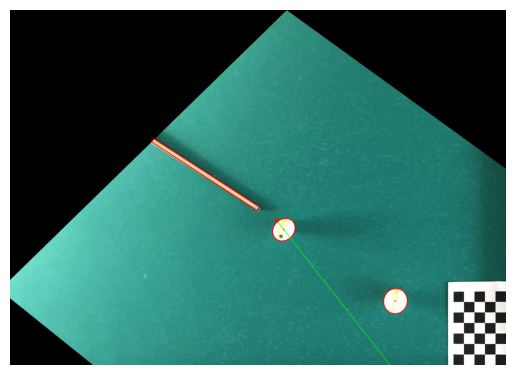

In [7]:
cue_balls_real_traj = cue_balls.copy()

x1 = np.intp((cue[0][0] + cue[1][0]) / 2)
y1 = np.intp((cue[0][1] + cue[1][1]) / 2)

x2 = np.intp((cue[2][0] + cue[3][0]) / 2)
y2 =  np.intp((cue[2][1] + cue[3][1]) / 2)

p1 = (x1, y1)
p2 = (x2, y2)


ball = ellipses[1]
center = (ball[0][0], ball[0][1])
radius = np.sqrt((ball[1][0] / 2) * (ball[1][1] / 2))

intersections = find_line_circle_intersections(p1, p2, center, radius)

for pt in intersections:
    cv2.circle(
        cue_balls_real_traj, 
        (int(pt[0]), int(pt[1])), 
        15, (0, 0, 255), -1
    )
    
traj_start = intersections[0]
direction = (center[0] - traj_start[0], center[1] - traj_start[1])
norm = np.sqrt(direction[0]**2 + direction[1]**2)

unit_direction = (direction[0] / norm, direction[1] / norm)
ray_length = 1500  
ray_end = (traj_start[0] + unit_direction[0] * ray_length, 
            traj_start[1] + unit_direction[1] * ray_length)

cv2.line(
    cue_balls_real_traj, 
    (int(traj_start[0]), int(traj_start[1])), 
    (int(ray_end[0]), int(ray_end[1])), 
    (0, 255, 0), 4
)
    
plt.imshow(cv2.cvtColor(cue_balls_real_traj, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

#### Так как мы бьем не в центр шара, то он пойдет под углом и пройдет мимо второго шара

#### Чтобы смоделировать попадение одного шара в другой немного изменим траекторию шара 

In [8]:
cue_balls_fictive_traj = cue_balls.copy()

x1 = np.intp((cue[0][0] + cue[1][0]) / 2)
y1 = np.intp((cue[0][1] + cue[1][1]) / 2)

x2 = np.intp((cue[2][0] + cue[3][0]) / 2)
y2 =  np.intp((cue[2][1] + cue[3][1]) / 2)

p1 = (x1, y1)
p2 = (x2, y2)


ball1 = ellipses[1]
ball1_center = (ball1[0][0], ball1[0][1])
ball1_radius = np.sqrt((ball1[1][0] / 2) * (ball1[1][1] / 2))

intersections = find_line_circle_intersections(p1, p2, ball1_center, ball1_radius)

for pt in intersections:
    cv2.circle(
        cue_balls_fictive_traj, 
        (int(pt[0]), int(pt[1])), 
        15, (0, 0, 255), -1
    )
    
traj_start = intersections[0]
direction = (center[0] - traj_start[0], center[1] - traj_start[1])
norm = np.sqrt(direction[0]**2 + direction[1]**2)

unit_direction = (direction[0] / norm, direction[1] / norm)
ray_length = 1500  
ray_end = (traj_start[0] + unit_direction[0] * ray_length + 350, #!заданное смещение, чтобы шары соприкасались!
            traj_start[1] + unit_direction[1] * ray_length)


ball2 = ellipses[0] 
ball2_center = (ball2[0][0], ball2[0][1])
ball2_radius = np.sqrt((ball2[1][0] / 2) * (ball2[1][1] / 2))

In [9]:
def compute_collision_point(center1, radius1, center2, radius2):

    vec = np.array(center2, dtype=np.float32) - np.array(center1, dtype=np.float32)
    distance = np.linalg.norm(vec)
    
    if distance == 0:
        raise ValueError("Центры шаров совпадают!")
    
    unit_vector = vec / distance

    collision_point = np.array(center1, dtype=np.float32) + radius1 * unit_vector
    return tuple(collision_point)


def generate_points_on_line(p1, p2, step):
    x1, y1 = p1
    x2, y2 = p2
    dx = x2 - x1
    dy = y2 - y1
    distance = math.sqrt(dx**2 + dy**2)
    
    if distance == 0:
        return [p1]
    
    unit_vector = (dx/distance, dy/distance)
    points = []
    
    num_steps = int(distance / step)
    for i in range(num_steps + 1):
        x = x1 + i * step * unit_vector[0]
        y = y1 + i * step * unit_vector[1]
        points.append((x, y))
    
    if points[-1] != p2:
        points.append(p2)
    return points

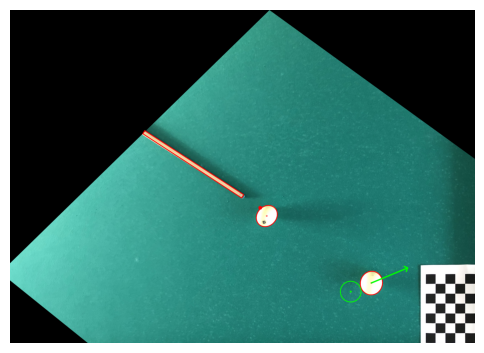

In [10]:
start_point = (int(traj_start[0]), int(traj_start[1]))
step = 5

points = generate_points_on_line(start_point, ray_end, step)

collision_ball_pos = None
for p in points:
    collision_point = compute_collision_point(
        (p[0], p[1]), 
        ball1_radius, 
        ball2_center, 
        ball2_radius,
    )
    vec = np.array((p[0], p[1])) - np.array(ball2_center)
    current_distance = np.linalg.norm(vec)
    
    if np.isclose(current_distance, ball1_radius + ball2_radius, atol=5):
        cv2.circle(
            cue_balls_fictive_traj, 
            (np.intp(p[0]), np.intp(p[1])), 
            np.intp(ball1_radius), 
            (0, 255, 0), 5
        )
        cv2.circle(
            cue_balls_fictive_traj, 
            (np.intp(p[0]), np.intp(p[1])), 
            5, (0, 255, 0), 5
        )
        collision_ball_pos = p
        break
    
    
direction = (ball2_center[0] - collision_ball_pos[0], 
             ball2_center[1] - collision_ball_pos[1])
norm = np.sqrt(direction[0]**2 + direction[1]**2)
unit_direction = (direction[0] / norm, direction[1] / norm)    

ray_length = 500  
ray_end = (collision_ball_pos[0] + unit_direction[0] * ray_length, 
            collision_ball_pos[1] + unit_direction[1] * ray_length)
        
        
cv2.arrowedLine(
    cue_balls_fictive_traj, 
    (int(ball2_center[0]), int(ball2_center[1])), 
    (int(ray_end[0]), int(ray_end[1])), 
    (0, 255, 0), 10
)
    
plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(cue_balls_fictive_traj, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

#### Я подобрал такую траекторию шара, чтобы он сталкивался со вторым шаром 

#### Теперь смоделируем ситацию, как будто мы попали в центр шара

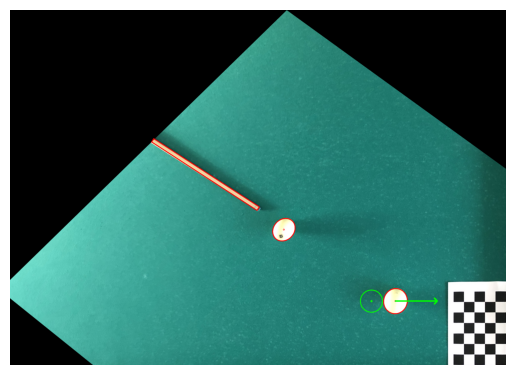

In [ ]:
cue_balls_best_traj = cue_balls.copy()
x2 = np.intp((cue[2][0] + cue[3][0]) / 2)
y2 =  np.intp((cue[2][1] + cue[3][1]) / 2)

p2 = (x2, y2)

direction = (ball1_center[0] - p2[0], 
             ball1_center[1] - p2[1])
norm = np.sqrt(direction[0]**2 + direction[1]**2)
unit_direction = (direction[0] / norm, direction[1] / norm)    

ray_length = 1500  
ray_end = (ball1_center[0] + unit_direction[0] * ray_length, 
            ball1_center[1] + unit_direction[1] * ray_length)


start_point = (int(ball1_center[0]), int(ball1_center[1]))
step = 5

points = generate_points_on_line(start_point, ray_end, step)

collision_ball_pos = None
for p in points:
    collision_point = compute_collision_point(
        (p[0], p[1]), 
        ball1_radius, 
        ball2_center, 
        ball2_radius,
    )
    vec = np.array((p[0], p[1])) - np.array(ball2_center)
    current_distance = np.linalg.norm(vec)
    
    if np.isclose(current_distance, ball1_radius + ball2_radius, atol=5):
        cv2.circle(
            cue_balls_best_traj, 
            (np.intp(p[0]), np.intp(p[1])), 
            np.intp(ball1_radius), 
            (0, 255, 0), 5
        )
        cv2.circle(
            cue_balls_best_traj, 
            (np.intp(p[0]), np.intp(p[1])), 
            5, (0, 255, 0), 5
        )
        collision_ball_pos = p
        break
    
direction = (ball2_center[0] - collision_ball_pos[0], 
             ball2_center[1] - collision_ball_pos[1])
norm = np.sqrt(direction[0]**2 + direction[1]**2)
unit_direction = (direction[0] / norm, direction[1] / norm)    

ray_length = 500  
ray_end = (collision_ball_pos[0] + unit_direction[0] * ray_length, 
            collision_ball_pos[1] + unit_direction[1] * ray_length)
        
        
cv2.arrowedLine(
    cue_balls_best_traj, 
    (int(ball2_center[0]), int(ball2_center[1])), 
    (int(ray_end[0]), int(ray_end[1])), 
    (0, 255, 0), 10
)

plt.imshow(cv2.cvtColor(cue_balls_best_traj, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()